In [2]:
import pandas as pd

df = pd.read_csv("../datasets/ds_salaries.csv")

df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [3]:
print(df.columns)

print(df.info())

print(df.describe())

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size    

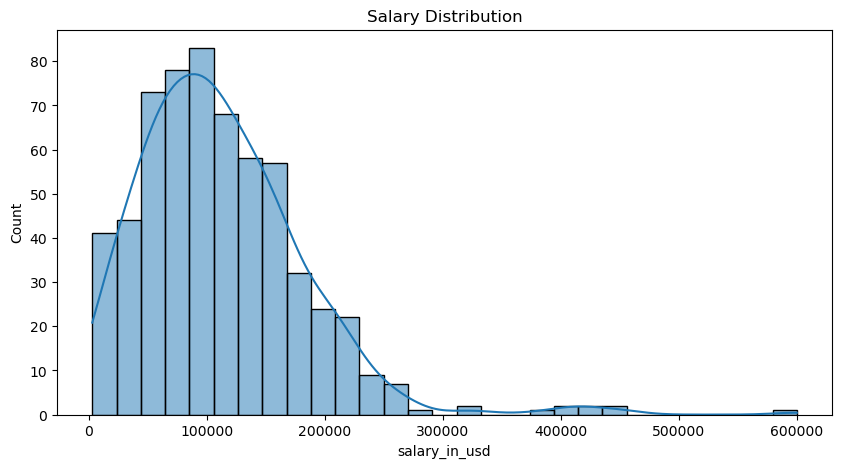

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(df["salary_in_usd"], kde=True)

plt.title("Salary Distribution")

plt.show()

In [5]:
df[[
    "experience_level",
    "employment_type",
    "remote_ratio",
    "company_size",
    "salary_in_usd"
]].head()

,experience_level,employment_type,remote_ratio,company_size,salary_in_usd
0,MI,FT,0,L,79833
1,SE,FT,0,S,260000
2,SE,FT,50,M,109024
3,MI,FT,0,S,20000
4,SE,FT,50,L,150000


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["experience_level"] = le.fit_transform(df["experience_level"])

df["employment_type"] = le.fit_transform(df["employment_type"])

df["company_size"] = le.fit_transform(df["company_size"])

X = df[[
    "experience_level",
    "employment_type",
    "remote_ratio",
    "company_size"
]]

y = df["salary_in_usd"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:5])

[133506.44810274 133506.44810274 113362.32858448 186998.24857155
 112185.16294104]


In [10]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 41592.18713562171


In [12]:
import joblib

joblib.dump(model, "../models/salary_model.pkl")

['../models/salary_model.pkl']